# Laptop data set cleaning, data analysis, and regression

This notebook goes through the process of cleaning datasets with a combination of pandas, numpy, and re. By the end of this notebook we will have a clean data set, 3 candidate models (initial, engineered features, pruned), and shapley plots to interpret the models findings. 

## Step 1: Loading first dataset

In [1]:
import numpy as np
import pandas as pd
import sys
import re

In [2]:
# Looking at original features
# if this does not work, go to https://www.kaggle.com/datasets/ehtishamsadiq/uncleaned-laptop-price-dataset/code, download and replace the contents of pd.read_csv with the file path prefaced by an r (ie r"myfilepath")
laptop_raw = pd.read_csv(r"C:\Users\whoop\Downloads\laptopData.csv")
# the below function converts 
def rupee_conversion():
    first_run_check = 0
    if first_run_check == 0:
        laptop_raw['Price'] = laptop_raw['Price']/284.9
        first_run_check += 1
    else: pass
rupee_conversion()
display(laptop_raw.head())
display(laptop_raw.info())

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,250.539429
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,168.113455
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,107.532468
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,474.536104
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,337.296623


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


None

## Step 2: Cleaning Numerical Features

In [3]:
# Inches should clearly be numerical data, it is saved an object. Let's examine unique values and clean invalid ones
laptop_raw.dtypes
display(laptop_raw['Inches'].unique())
# We can see there are values that are nan and there is one that is '?', let's replace them with np.nan
laptop_raw.replace(to_replace='?', value=np.nan, inplace=True)
laptop_raw.replace(to_replace='nan', value=np.nan, inplace=True)
laptop_raw['Inches'] = laptop_raw['Inches'].astype(np.float64)
display(laptop_raw.dtypes)

array(['13.3', '15.6', '15.4', '14', '12', nan, '17.3', '13.5', '12.5',
       '13', '18.4', '13.9', '11.6', '25.6', '35.6', '12.3', '27.3', '24',
       '33.5', '?', '31.6', '17', '15', '14.1', '11.3', '10.1'],
      dtype=object)

Unnamed: 0          float64
Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object

In [4]:
display(laptop_raw['Memory'].unique())
# extract_storage_type looks for anything that has numbers in it then returns the alphabetical parts, giving us the storage type
def extract_storage_type(s):
    if pd.isnull(s):
        return np.nan
    parts = re.findall(r'\d+\.?\d*\s*(?:GB|TB)\s*([A-Za-z ]+)', s)
    return ' + '.join(part.strip() for part in parts)
# applying extract_storage type
laptop_raw['Storage Type'] = laptop_raw['Memory'].apply(extract_storage_type)

# This function totals our storage in GB, handles TB by converting to GB
def total_storage_in_gb(s):
    if not isinstance(s, str):
        return np.nan

    matches = re.findall(r'\d+\.?\d*\s*(?:GB|TB)', s)
    total_gb = 0

    for item in matches:
        number = float(re.search(r'\d+\.?\d*', item).group())
        if 'TB' in item:
            number *= 1024
        total_gb += number

    return round(float(total_gb), 0)
# applying total_storage_in_gb
laptop_raw['Memory'] = laptop_raw['Memory'].apply(total_storage_in_gb).astype('float64')
display(laptop_raw['Storage Type'].unique())
display(laptop_raw['Memory'].unique())
display(laptop_raw.dtypes)

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD', nan,
       '128GB SSD +  1TB HDD', '256GB SSD +  256GB SSD',
       '64GB Flash Storage', '32GB Flash Storage', '256GB SSD +  1TB HDD',
       '256GB SSD +  2TB HDD', '32GB SSD', '2TB HDD', '64GB SSD',
       '1.0TB Hybrid', '512GB SSD +  1TB HDD', '1TB SSD',
       '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

array(['SSD', 'Flash Storage', 'HDD', nan, 'SSD + HDD', 'SSD + SSD',
       'Hybrid', 'Flash Storage + HDD', 'HDD + HDD', 'SSD + Hybrid'],
      dtype=object)

array([ 128.,  256.,  512.,  500., 1024.,   nan, 1152.,   64.,   32.,
       1280., 2304., 2048., 1536.,  756., 2176.,   16.,  768., 2560.,
       1088.,  180.,  240.,    8.,  508.])

Unnamed: 0          float64
Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory              float64
Gpu                  object
OpSys                object
Weight               object
Price               float64
Storage Type         object
dtype: object

In [5]:
# Ram is another numerical feature saved as object, let's examine the unique values to confirm they are all in the same unit then strip non numeric characters
display(laptop_raw['Ram'].unique())
# Ram is all in GB, we will use this lambda function and some regex to strip away anything non numeric
laptop_raw['Ram'] = laptop_raw['Ram'].apply(lambda x: re.sub('[^0-9.]', '', x) if isinstance(x, str) else x).replace('', np.nan).astype(('float64'))
display(laptop_raw['Ram'].unique())
display(laptop_raw.dtypes)

array(['8GB', '16GB', '4GB', nan, '2GB', '12GB', '64GB', '6GB', '32GB',
       '24GB', '1GB'], dtype=object)

array([ 8., 16.,  4., nan,  2., 12., 64.,  6., 32., 24.,  1.])

Unnamed: 0          float64
Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                 float64
Memory              float64
Gpu                  object
OpSys                object
Weight               object
Price               float64
Storage Type         object
dtype: object

In [6]:
display(laptop_raw['Weight'].unique())
laptop_raw['Weight'] = laptop_raw['Weight'].apply(lambda x: re.sub('[^0-9.]', '', x) if isinstance(x, str) else x).replace('', np.nan).astype(('float64'))
laptop_raw['Weight'].replace(0.0002, np.nan)
display(laptop_raw['Weight'].unique())

array(['1.37kg', '1.34kg', '1.86kg', '1.83kg', '2.1kg', '2.04kg', '1.3kg',
       '1.6kg', '2.2kg', '0.92kg', '1.22kg', nan, '2.5kg', '1.62kg',
       '1.91kg', '2.3kg', '1.35kg', '1.88kg', '1.89kg', '1.65kg',
       '2.71kg', '1.2kg', '1.44kg', '2.8kg', '2kg', '2.65kg', '2.77kg',
       '3.2kg', '1.49kg', '2.4kg', '2.13kg', '2.43kg', '1.7kg', '1.4kg',
       '1.8kg', '1.9kg', '3kg', '1.252kg', '2.7kg', '2.02kg', '1.63kg',
       '1.96kg', '1.21kg', '2.45kg', '1.25kg', '1.5kg', '2.62kg',
       '1.38kg', '1.58kg', '1.85kg', '1.23kg', '2.16kg', '2.36kg',
       '7.2kg', '2.05kg', '1.32kg', '1.75kg', '0.97kg', '2.56kg',
       '1.48kg', '1.74kg', '1.1kg', '1.56kg', '2.03kg', '1.05kg', '5.4kg',
       '4.4kg', '1.90kg', '1.29kg', '2.0kg', '1.95kg', '2.06kg', '1.12kg',
       '3.49kg', '3.35kg', '2.23kg', '2.9kg', '4.42kg', '2.69kg',
       '2.37kg', '4.7kg', '3.6kg', '2.08kg', '4.3kg', '1.68kg', '1.41kg',
       '4.14kg', '2.18kg', '2.24kg', '2.67kg', '4.1kg', '2.14kg',
       '1.36kg', '

array([1.370e+00, 1.340e+00, 1.860e+00, 1.830e+00, 2.100e+00, 2.040e+00,
       1.300e+00, 1.600e+00, 2.200e+00, 9.200e-01, 1.220e+00,       nan,
       2.500e+00, 1.620e+00, 1.910e+00, 2.300e+00, 1.350e+00, 1.880e+00,
       1.890e+00, 1.650e+00, 2.710e+00, 1.200e+00, 1.440e+00, 2.800e+00,
       2.000e+00, 2.650e+00, 2.770e+00, 3.200e+00, 1.490e+00, 2.400e+00,
       2.130e+00, 2.430e+00, 1.700e+00, 1.400e+00, 1.800e+00, 1.900e+00,
       3.000e+00, 1.252e+00, 2.700e+00, 2.020e+00, 1.630e+00, 1.960e+00,
       1.210e+00, 2.450e+00, 1.250e+00, 1.500e+00, 2.620e+00, 1.380e+00,
       1.580e+00, 1.850e+00, 1.230e+00, 2.160e+00, 2.360e+00, 7.200e+00,
       2.050e+00, 1.320e+00, 1.750e+00, 9.700e-01, 2.560e+00, 1.480e+00,
       1.740e+00, 1.100e+00, 1.560e+00, 2.030e+00, 1.050e+00, 5.400e+00,
       4.400e+00, 1.290e+00, 1.950e+00, 2.060e+00, 1.120e+00, 3.490e+00,
       3.350e+00, 2.230e+00, 2.900e+00, 4.420e+00, 2.690e+00, 2.370e+00,
       4.700e+00, 3.600e+00, 2.080e+00, 4.300e+00, 

## Step 3: Cleaning Categorical Features

### There are quite a few models of CPU, which will make visualizing the data difficult, let's break it down into these groups
#### For AMD it seems they have 4 different series of CPU within this data:
1. AMD A Series
2. AMD E-Series
3. AMD FX
4. AMD Ryzen
<br> 
#### Then for Intel they have:
1. Intel Atom
2. Intel Celeron Dual Core
3. Intel Celeron Quad Core
4. Intel Core i3
5. Intel Core i5
6. Intel Core i7
7. Intel Core M
8. Intel Pentium Dual Core 
9. Intel Pentium Quad Core
10. Intel Xeon

In [7]:
# here we narrow the CPUs down to brand and series
CPU_PATTERNS = [
    (r'AMD A\d+[ -]Series', 'AMD A-Series'),
    (r'AMD E\d*[ -]Series', 'AMD E-Series'),
    (r'AMD FX(?:\s*\d+)?', 'AMD FX'),
    (r'AMD Ryzen(?:\s*\d+)?', 'AMD Ryzen'),
    (r'Intel Atom(?:\s*\w+)?', 'Intel Atom'),
    (r'Intel Celeron Dual Core.*', 'Intel Celeron Dual Core'),
    (r'Intel Celeron Quad Core.*', 'Intel Celeron Quad Core'),
    (r'Intel Core i3(?:[- ]?\d{4,5}[A-Z]*)?', 'Intel Core i3'),
    (r'Intel Core i5(?:[- ]?\d{4,5}[A-Z]*)?', 'Intel Core i5'),
    (r'Intel Core i7(?:[- ]?\d{4,5}[A-Z]*)?', 'Intel Core i7'),
    (r'Intel Core M(?:\s*\w+)?', 'Intel Core M'),
    (r'Intel Pentium Dual Core.*', 'Intel Pentium Dual Core'),
    (r'Intel Pentium Quad Core.*', 'Intel Pentium Quad Core'),
    (r'Intel Xeon.*', 'Intel Xeon'),
]

def extract_cpus(df, column='Cpu', new_column='Cpu Brand'):
    def label_cpu(text):
        if pd.isnull(text):
            return ''
        for pat, label in CPU_PATTERNS:
            if re.search(pat, text, flags=re.IGNORECASE):
                return label
        return ''
    df[new_column] = df[column].apply(label_cpu)
    return df

laptop_raw = extract_cpus(laptop_raw, column='Cpu', new_column='Cpu Brand')

#The CPU pattern before produced over a dozen bars when visualized, to make this simpler we'll lump some Series together

CPU_PATTERNS = [
    (r'AMD A\d+[ -]Series', 'AMD Series'),
    (r'AMD E\d*[ -]Series', 'AMD Series'),
    (r'AMD Series', 'AMD Series'),
    (r'AMD FX(?:\s*\d+)?', 'AMD FX'),
    (r'AMD Ryzen(?:\s*\d+)?', 'AMD Ryzen'),
    (r'Intel Atom(?:\s*\w+)?', 'Intel Atom'),
    (r'Intel Celeron(?:\s+\w+)?', 'Intel Celeron'),
    (r'Intel Core i[3579](?:[- ]?\d{4,5}[A-Z]*)?', 'Intel Core'),
    (r'Intel Core M(?:\s*\w+)?', 'Intel Core'),
    (r'Intel Pentium(?:\s+\w+)?', 'Intel Pentium'),
    (r'Intel Xeon(?:.*)?', 'Intel Xeon')
]

laptop_raw = extract_cpus(laptop_raw, column='Cpu', new_column='Cpu Brand Concise')

display(laptop_raw.head())
display(laptop_raw['Cpu Brand Concise'].unique())

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Storage Type,Cpu Brand,Cpu Brand Concise
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,1.37,250.539429,SSD,Intel Core i5,Intel Core
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,1.34,168.113455,Flash Storage,Intel Core i5,Intel Core
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,1.86,107.532468,SSD,Intel Core i5,Intel Core
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,1.83,474.536104,SSD,Intel Core i7,Intel Core
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,1.37,337.296623,SSD,Intel Core i5,Intel Core


array(['Intel Core', 'AMD Series', '', 'Intel Atom', 'Intel Celeron',
       'AMD Ryzen', 'Intel Pentium', 'AMD FX', 'Intel Xeon'], dtype=object)

In [8]:
# 5. Creating GPU regex patterns to narrow down GPU
GPU_PATTERNS = [
    (r'AMD\s+FirePro(?:\s*[\w-]+)?',                'AMD FirePro'),
    (r'AMD\s+Radeon\s+Pro(?:\s*[\w-]+)?',           'AMD Radeon Pro'),
    (r'AMD\s+Radeon\s+RX(?:\s*[\w-]+)?',            'AMD Radeon RX'),
    (r'AMD\s+Radeon(?!\s+(Pro|RX))(?:\s*[\w-]+)?',  'AMD Radeon'),
    (r'AMD\s+Graphics(?:\s*[\w-]+)?',               'AMD Graphics'),
    (r'ARM\s+Mali(?:\s*[\w-]+)?',                   'ARM Mali'),
    (r'Nvidia\s+GeForce\s+GTX(?:\s*[\w-]+)?',       'Nvidia GeForce GTX'),
    (r'Nvidia\s+GeForce\s+MX(?:\s*[\w-]+)?',        'Nvidia GeForce MX'),
    (r'Nvidia\s+Quadro(?:\s*[\w-]+)?',              'Nvidia Quadro'),
    (r'Intel\s+Iris\s+Pro\s+Graphics(?:\s*[\w-]+)?','Intel Iris Pro Graphics'),
    (r'Intel\s+Iris\s+Plus\s+Graphics(?:\s*[\w-]+)?','Intel Iris Plus Graphics'),
    (r'Intel\s+Iris\s+Graphics(?:\s*[\w-]+)?',     'Intel Iris Graphics'),
    (r'Intel\s+UHD\s+Graphics(?:\s*[\w-]+)?',      'Intel UHD Graphics'),
    (r'Intel\s+HD\s+Graphics(?:\s*[\w-]+)?',       'Intel HD Graphics'),
    (r'Intel\s+Graphics(?:\s*[\w-]+)?',            'Intel Graphics'),
]

def extract_gpus(df, column='Gpu', new_column='Gpu Brand'):
    def label_gpu(text):
        if pd.isnull(text):
            return ''
        for pat, label in GPU_PATTERNS:
            if re.search(pat, text, flags=re.IGNORECASE):
                return label
        return ''
    df[new_column] = df[column].apply(label_gpu)
    return df

laptop_raw = extract_gpus(laptop_raw, column='Gpu', new_column='Gpu Brand')

# Creating concise patterns in regex patterns to further narrow down GPU
GPU_PATTERNS = [
    (r'AMD\s+FirePro(?:\s*[\w-]+)?',                'AMD FirePro'),
    (r'AMD\s+Radeon\s+Pro(?:\s*[\w-]+)?',           'AMD Radeon Pro'),
    (r'AMD\s+Radeon\s+RX(?:\s*[\w-]+)?',            'AMD Radeon RX'),
    (r'AMD\s+Radeon(?!\s+(Pro|RX))(?:\s*[\w-]+)?',  'AMD Radeon'),
    (r'AMD\s+Graphics(?:\s*[\w-]+)?',               'AMD Graphics'),
    (r'ARM\s+Mali(?:\s*[\w-]+)?',                   'ARM Mali'),
    (r'Nvidia\s+GeForce\s+GTX(?:\s*[\w-]+)?',       'Nvidia GeForce GTX'),
    (r'Nvidia\s+GeForce\s+MX(?:\s*[\w-]+)?',        'Nvidia GeForce MX'),
    (r'Nvidia\s+Quadro(?:\s*[\w-]+)?',              'Nvidia Quadro'),
    (r'Intel\s+Iris\s+Pro\s+Graphics(?:\s*[\w-]+)?','Intel Iris Pro Graphics'),
    (r'Intel\s+Iris\s+Plus\s+Graphics(?:\s*[\w-]+)?','Intel Iris Plus Graphics'),
    (r'Intel\s+Iris\s+Graphics(?:\s*[\w-]+)?',      'Intel Iris Graphics'),
    (r'Intel\s+UHD\s+Graphics(?:\s*[\w-]+)?',       'Intel UHD Graphics'),
    (r'Intel\s+HD\s+Graphics(?:\s*[\w-]+)?',        'Intel HD Graphics'),
    (r'Intel\s+Graphics(?:\s*[\w-]+)?',             'Intel Graphics'),
]
laptop_raw = extract_gpus(laptop_raw, column='Gpu', new_column='Gpu Brand Concise')

display(laptop_raw.head())
display(laptop_raw['Gpu Brand Concise'].unique())

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Storage Type,Cpu Brand,Cpu Brand Concise,Gpu Brand,Gpu Brand Concise
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,1.37,250.539429,SSD,Intel Core i5,Intel Core,Intel Iris Plus Graphics,Intel Iris Plus Graphics
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,1.34,168.113455,Flash Storage,Intel Core i5,Intel Core,Intel HD Graphics,Intel HD Graphics
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,1.86,107.532468,SSD,Intel Core i5,Intel Core,Intel HD Graphics,Intel HD Graphics
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,1.83,474.536104,SSD,Intel Core i7,Intel Core,AMD Radeon Pro,AMD Radeon Pro
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,1.37,337.296623,SSD,Intel Core i5,Intel Core,Intel Iris Plus Graphics,Intel Iris Plus Graphics


array(['Intel Iris Plus Graphics', 'Intel HD Graphics', 'AMD Radeon Pro',
       'AMD Radeon', 'Intel Iris Pro Graphics', 'Nvidia GeForce MX',
       'Intel UHD Graphics', '', 'Nvidia GeForce GTX',
       'Intel Iris Graphics', 'AMD Radeon RX', 'Nvidia Quadro',
       'AMD FirePro', 'Intel Graphics', 'ARM Mali'], dtype=object)

In [9]:
display(laptop_raw['ScreenResolution'].unique())
def parse_screen_resolution(resolution_str):
    if pd.isnull(resolution_str):
        return None, None
    
    # Extract pixel resolution
    match = re.search(r'(\d+)\s*[xX]\s*(\d+)', resolution_str)
    pixel_count = None
    if match:
        width, height = map(int, match.groups())
        pixel_count = width * height
    
    # Detect marketing terms
    marketing_terms = []
    terms_map = {
        'Retina': r'\bRetina\b',
        '4K': r'\b4K\b|\b3840x2160\b',
        'UHD': r'\bUHD\b',
        'Full HD': r'\bFull\s*HD\b|\b1920x1080\b',
        'Touchscreen': r'\bTouch\b|\bTouchscreen\b',
        'IPS Panel': r'\bIPS\b',
        'OLED': r'\bOLED\b',
        'QHD': r'\bQHD\b|\b2560x1440\b'
    }
    
    for label, pattern in terms_map.items():
        if re.search(pattern, resolution_str, flags=re.IGNORECASE):
            marketing_terms.append(label)
    
    marketing_str = ', '.join(marketing_terms) if marketing_terms else None
    
    return pixel_count, marketing_str

# Applying parse_screen_resolution via a lambda and .apply
laptop_raw[['PixelCount', 'DisplayFeatures']] = laptop_raw['ScreenResolution'].apply(
    lambda x: pd.Series(parse_screen_resolution(x))
)
display(laptop_raw['PixelCount'].unique())
display(laptop_raw['DisplayFeatures'].unique())
display(laptop_raw.head())

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080', nan,
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', '1600x900',
       'IPS Panel 4K Ultra HD 3840x2160', '4K Ultra HD 3840x2160',
       'Touchscreen 1366x768', 'Touchscreen 2560x1440',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel Quad HD+ 3200x1800',
       'IPS Pane

array([4096000., 1296000., 2073600., 5184000., 1049088., 3317760.,
            nan, 5760000., 3393024., 8294400., 3110400., 1440000.,
       3686400., 4990464., 3840000., 2304000.])

array(['Retina, IPS Panel', nan, 'Full HD', 'Full HD, IPS Panel',
       'Full HD, Touchscreen, IPS Panel', None, 'Full HD, Touchscreen',
       'Touchscreen', 'IPS Panel', '4K, Touchscreen, IPS Panel',
       '4K, Touchscreen', '4K, IPS Panel', '4K', 'Touchscreen, QHD',
       'IPS Panel, QHD', 'Full HD, IPS Panel, QHD', 'QHD',
       'Touchscreen, IPS Panel', 'Touchscreen, IPS Panel, QHD'],
      dtype=object)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Storage Type,Cpu Brand,Cpu Brand Concise,Gpu Brand,Gpu Brand Concise,PixelCount,DisplayFeatures
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,1.37,250.539429,SSD,Intel Core i5,Intel Core,Intel Iris Plus Graphics,Intel Iris Plus Graphics,4096000.0,"Retina, IPS Panel"
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,1.34,168.113455,Flash Storage,Intel Core i5,Intel Core,Intel HD Graphics,Intel HD Graphics,1296000.0,NaN
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,1.86,107.532468,SSD,Intel Core i5,Intel Core,Intel HD Graphics,Intel HD Graphics,2073600.0,Full HD
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,1.83,474.536104,SSD,Intel Core i7,Intel Core,AMD Radeon Pro,AMD Radeon Pro,5184000.0,"Retina, IPS Panel"
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,1.37,337.296623,SSD,Intel Core i5,Intel Core,Intel Iris Plus Graphics,Intel Iris Plus Graphics,4096000.0,"Retina, IPS Panel"


In [10]:
df = laptop_raw.drop(['ScreenResolution', 'Cpu', 'Gpu', 'Cpu Brand', 'Gpu Brand'], axis=1)
df = df.drop(columns=df.columns[df.columns.str.strip() == 'Unnamed: 0'])
display(df.head())

,Company,TypeName,Inches,Ram,Memory,OpSys,Weight,Price,Storage Type,Cpu Brand Concise,Gpu Brand Concise,PixelCount,DisplayFeatures
0,Apple,Ultrabook,13.3,8.0,128.0,macOS,1.37,250.539429,SSD,Intel Core,Intel Iris Plus Graphics,4096000.0,"Retina, IPS Panel"
1,Apple,Ultrabook,13.3,8.0,128.0,macOS,1.34,168.113455,Flash Storage,Intel Core,Intel HD Graphics,1296000.0,NaN
2,HP,Notebook,15.6,8.0,256.0,No OS,1.86,107.532468,SSD,Intel Core,Intel HD Graphics,2073600.0,Full HD
3,Apple,Ultrabook,15.4,16.0,512.0,macOS,1.83,474.536104,SSD,Intel Core,AMD Radeon Pro,5184000.0,"Retina, IPS Panel"
4,Apple,Ultrabook,13.3,8.0,256.0,macOS,1.37,337.296623,SSD,Intel Core,Intel Iris Plus Graphics,4096000.0,"Retina, IPS Panel"


## Step 4: Handling Missing Values

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


 Missing Values in Data:


DisplayFeatures    334
Memory              31
Inches              31
Storage Type        31
Weight              31
TypeName            30
Company             30
OpSys               30
Ram                 30
Price               30
PixelCount          30
dtype: int64

C:\Users\whoop\AppData\Local\Temp\ipykernel_19756\3401423265.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=missing.index, x=missing.values, palette="viridis")


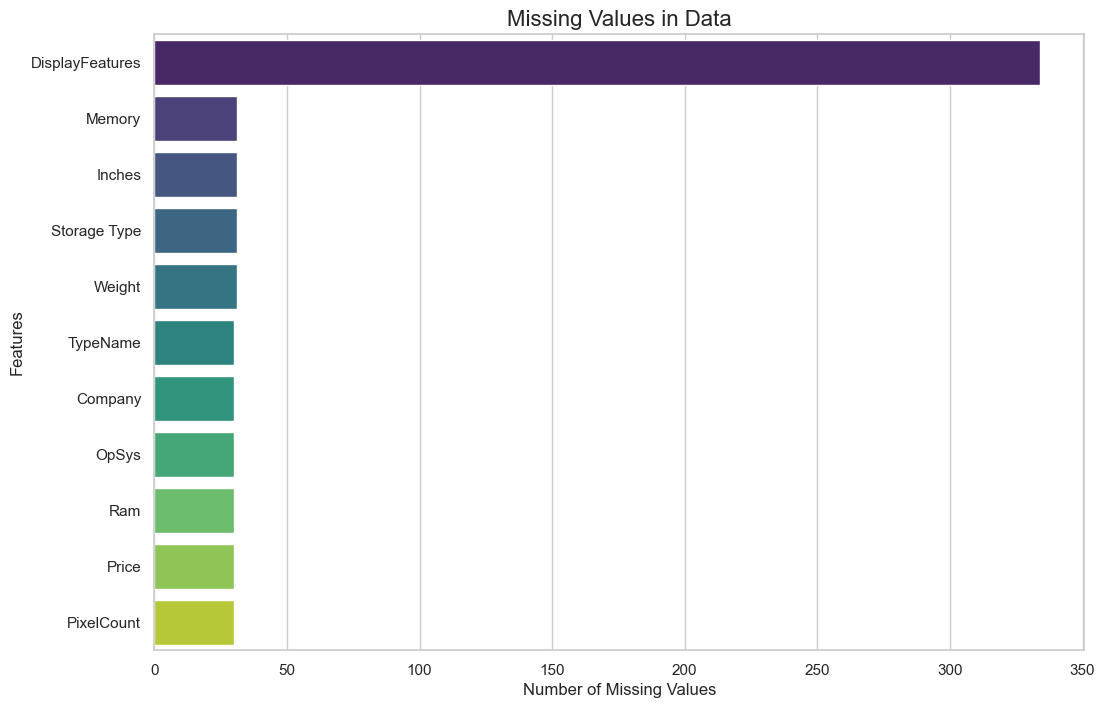

In [12]:
# 🔍 Check missing values for Training data
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\n Missing Values in Data:")
display(missing)

# 📊 Visualizing missing values (train data)
plt.figure(figsize=(12, 8))
sns.barplot(y=missing.index, x=missing.values, palette="viridis")
plt.title('Missing Values in Data', fontsize=16)
plt.xlabel('Number of Missing Values')
plt.ylabel('Features')
plt.show()

In [13]:
# This cell addresses missing values
df = df.copy()

# 1 Drop rows with missing target
df = df.dropna(subset=['Price'])

# 2 Categorical fills
cat_fill = {
    'DisplayFeatures': 'None',
    'Storage Type': 'Unknown',
    'TypeName': 'Unknown',
    'Company': 'Unknown',
    'OpSys': 'Unknown'
}
df.fillna(value=cat_fill)

# 3 Numeric fills
num_cols = ['Memory', 'Inches', 'Weight', 'Ram', 'PixelCount']
for col in num_cols:
    df[col].fillna(df[col].median())

## Step 5: Data Visualization

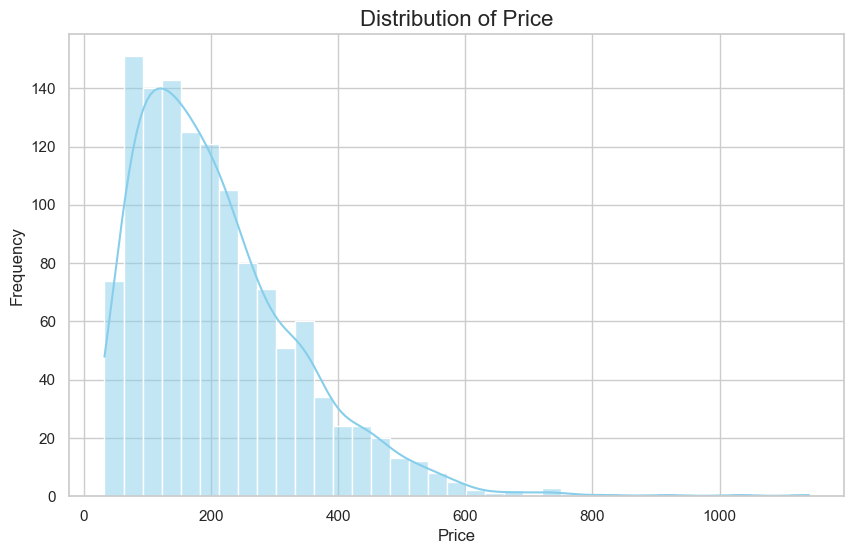

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price'], kde=True, color='skyblue')
plt.title('Distribution of Price', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

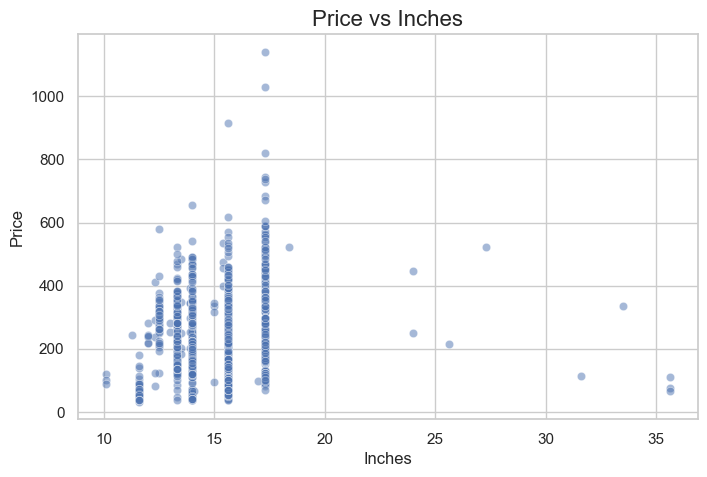

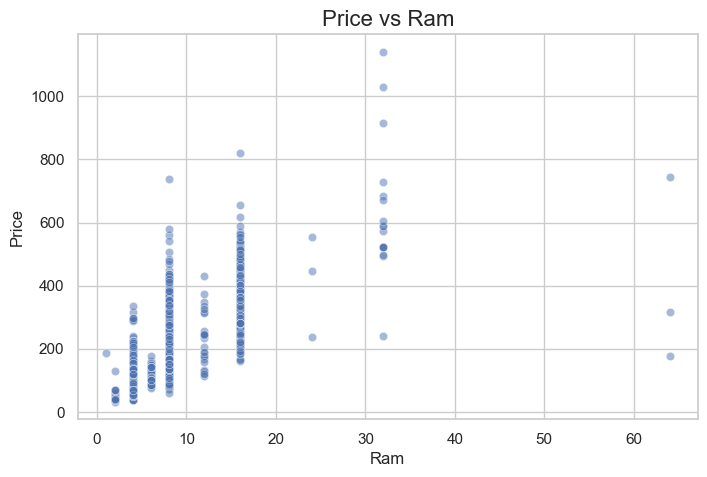

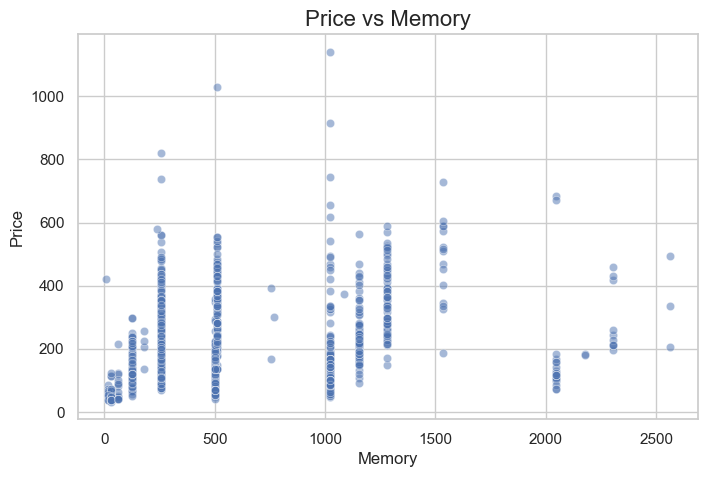

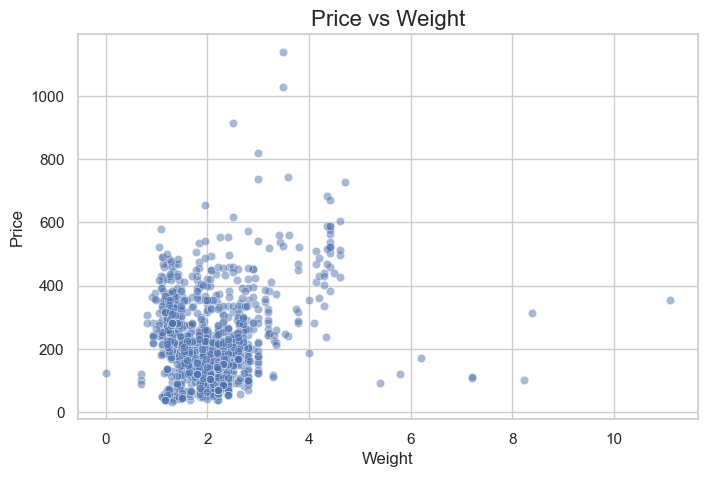

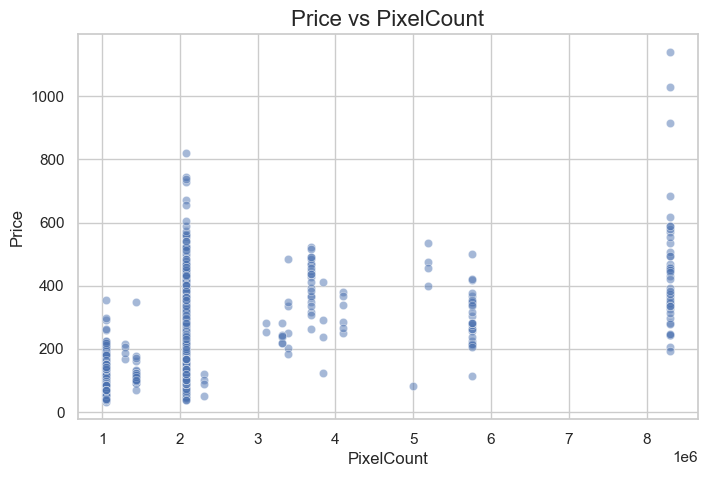

In [15]:
num_features = ['Inches', 'Ram', 'Memory', 'Weight', 'PixelCount']

for feature in num_features:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=df[feature], y=df['Price'], alpha=0.5)
    plt.title(f'Price vs {feature}', fontsize=16)
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.show()

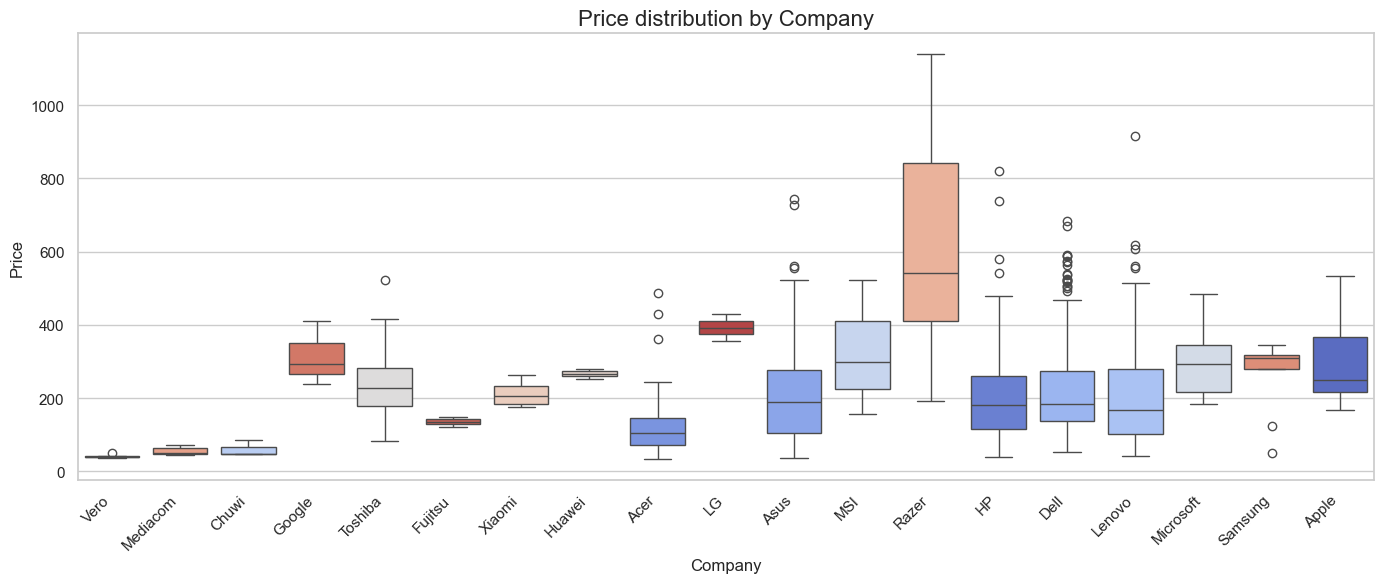

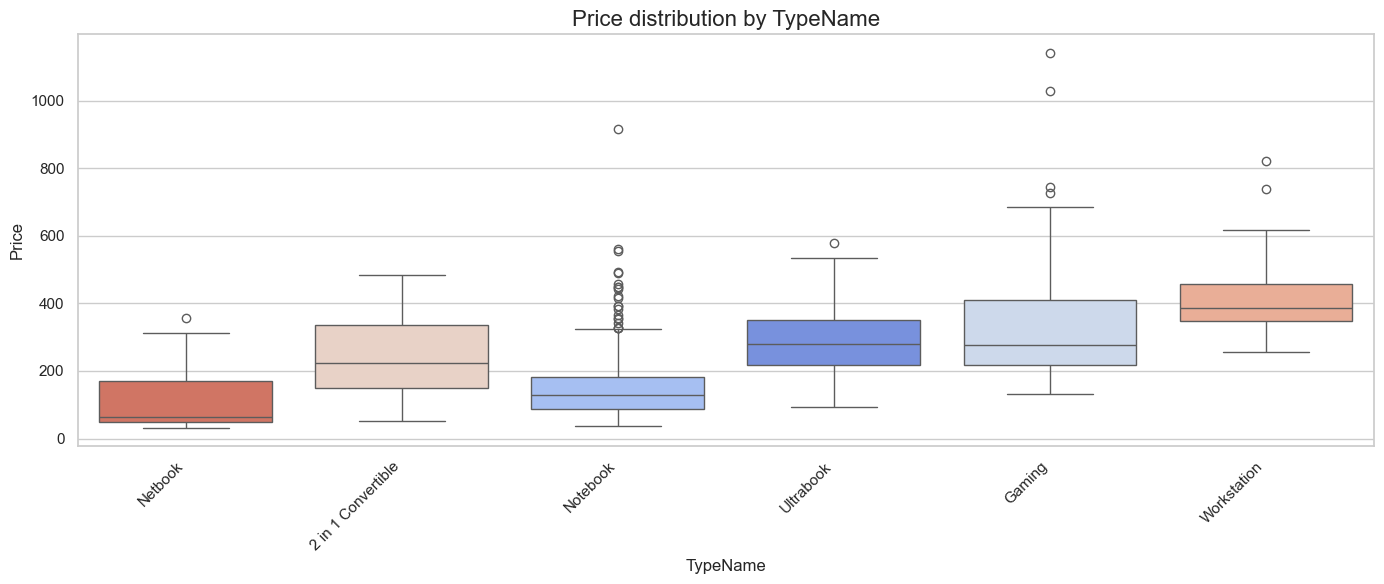

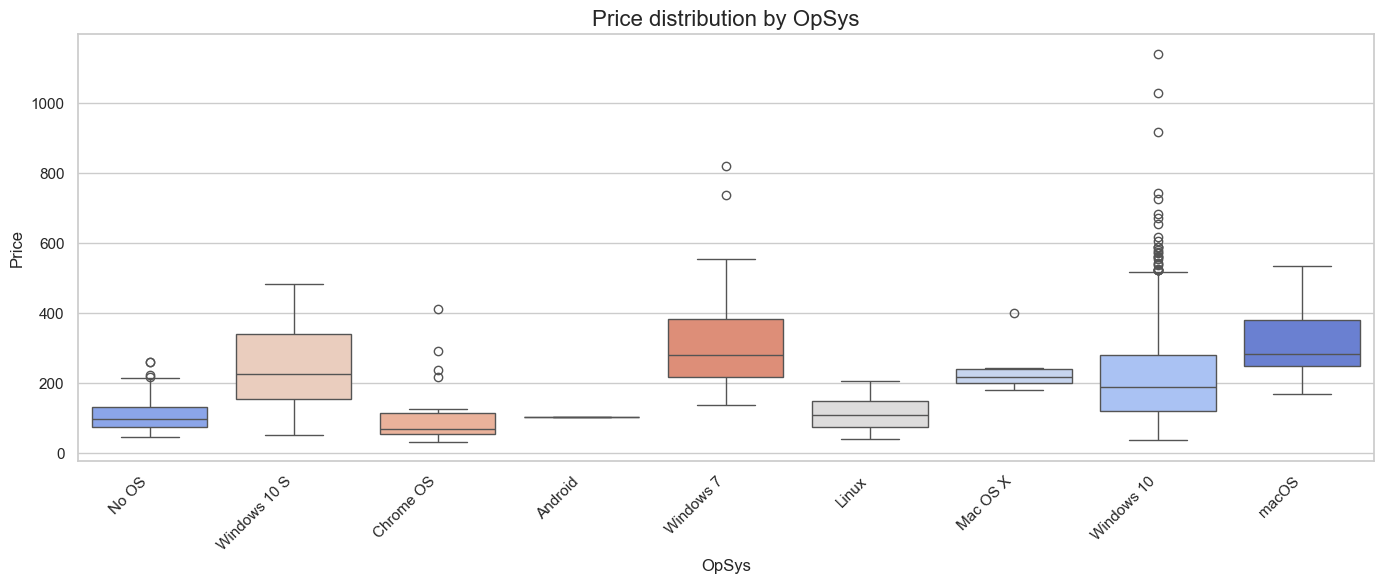

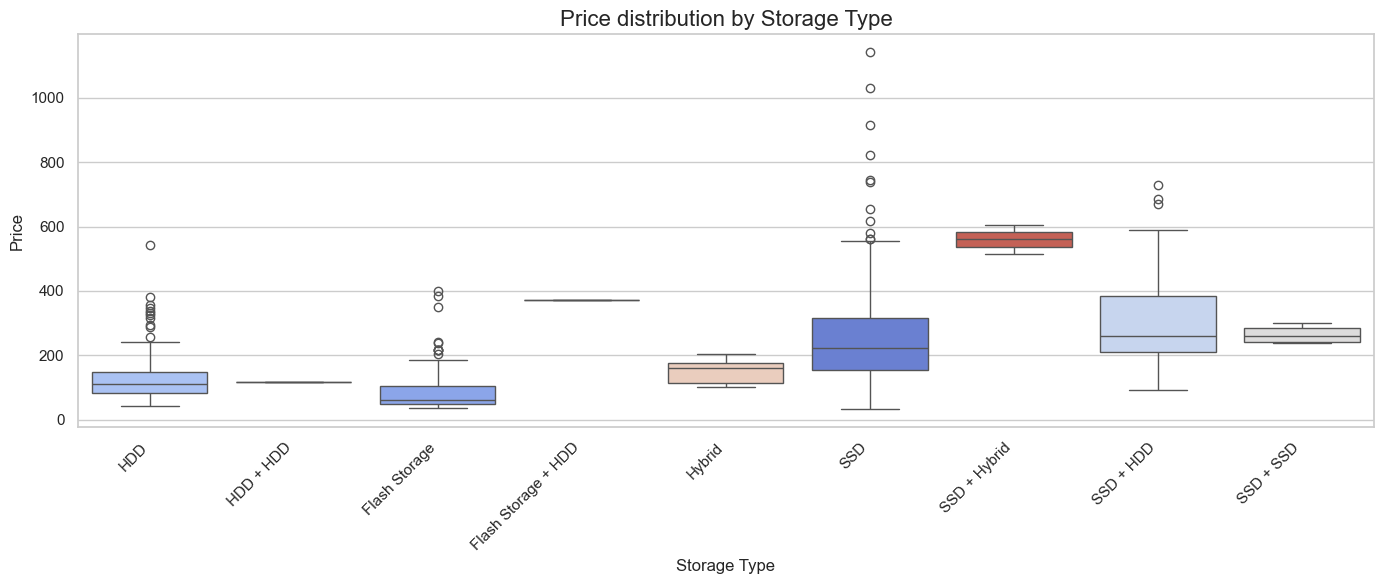

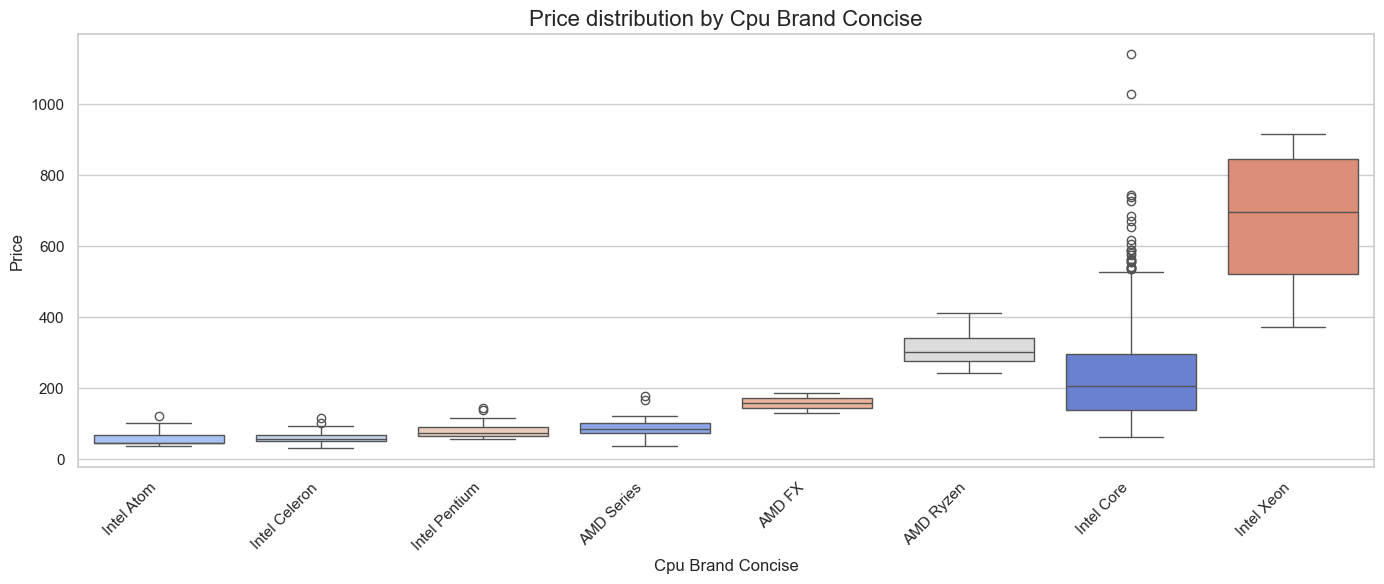

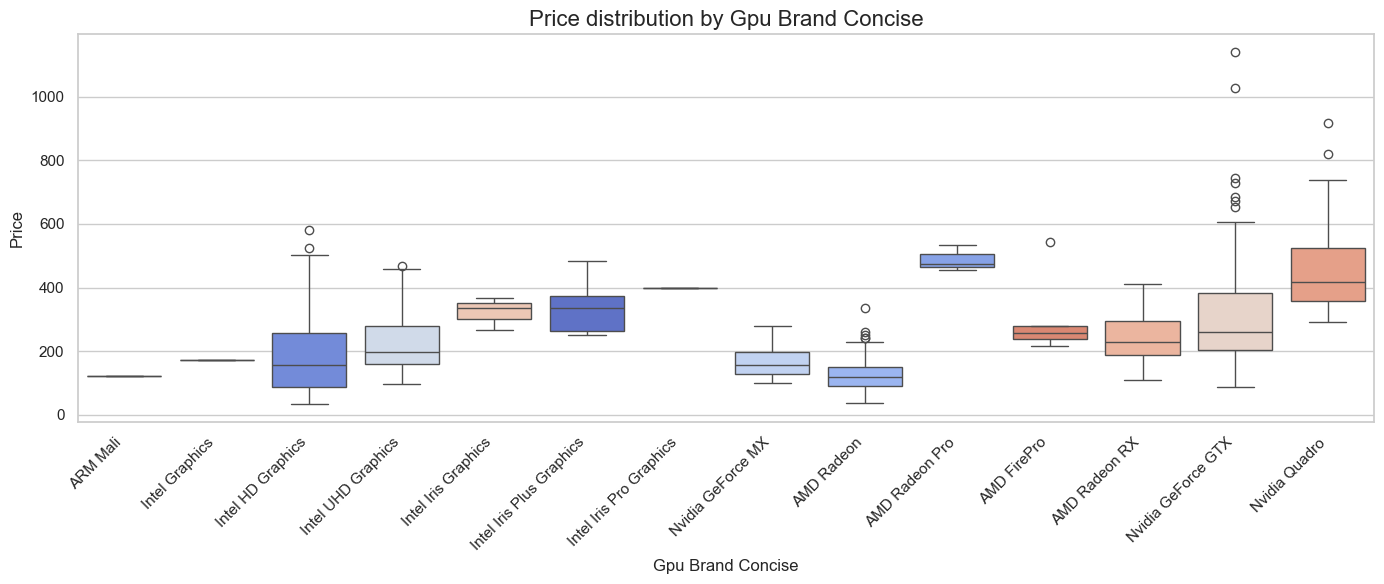

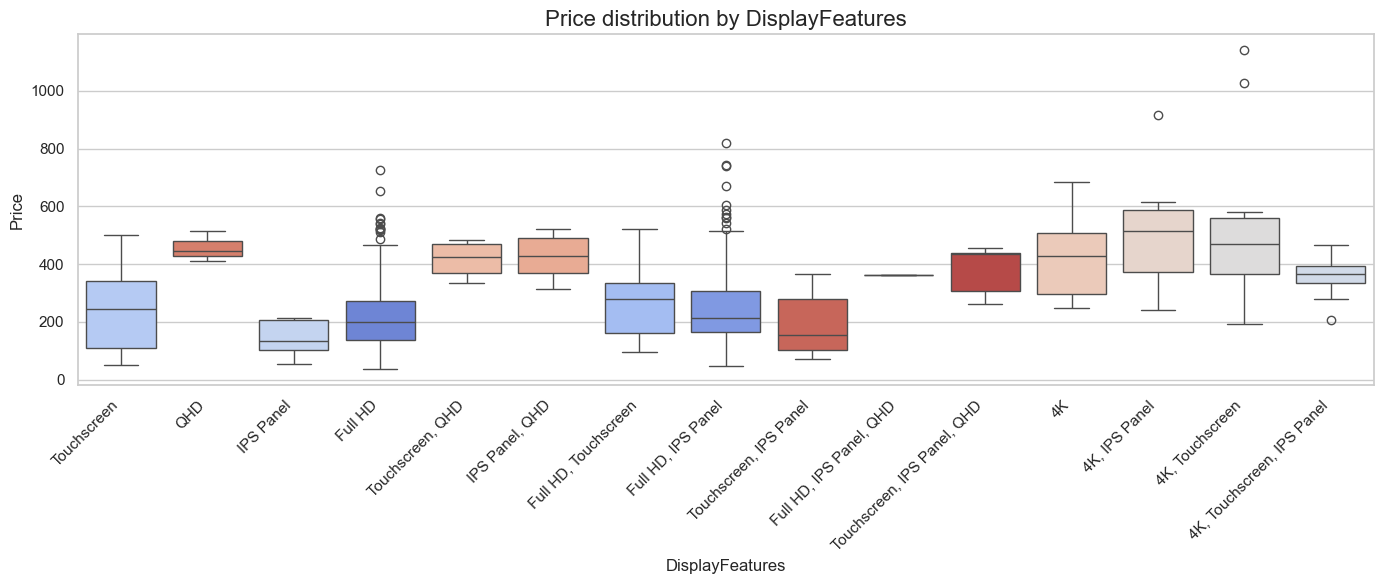

In [16]:
cat_features = [ 'Company', 'TypeName', 'OpSys', 'Storage Type', 'Cpu Brand Concise', 'Gpu Brand Concise', 'DisplayFeatures' ]

# Defining an explicit (domain based) order for each categorical feature
custom_orders = {
    "Company": [
        "Vero","Mediacom","Chuwi","Google","Toshiba","Fujitsu","Xiaomi",
        "Huawei","Acer","LG","Asus","MSI","Razer","HP","Dell","Lenovo",
        "Microsoft","Samsung","Apple"
    ],
    "TypeName": [
        "Netbook","2 in 1 Convertible","Notebook","Ultrabook","Gaming","Workstation"
    ],
    "OpSys": [
        "No OS","Windows 10 S","Chrome OS","Android","Windows 7","Linux",
        "Mac OS X","Windows 10","macOS"
    ],
    "Storage Type": [
        "HDD","HDD + HDD","Flash Storage","Flash Storage + HDD",
        "Hybrid","SSD","SSD + Hybrid","SSD + HDD","SSD + SSD"
    ],
    "Cpu Brand Concise": [
        "Intel Atom","Intel Celeron","Intel Pentium","AMD Series","AMD FX",
        "AMD Ryzen","Intel Core","Intel Xeon"
    ],
    "Gpu Brand Concise": [
        "ARM Mali","Intel Graphics","Intel HD Graphics","Intel UHD Graphics",
        "Intel Iris Graphics","Intel Iris Plus Graphics","Intel Iris Pro Graphics",
        "Nvidia GeForce MX","AMD Radeon","AMD Radeon Pro","AMD FirePro",
        "AMD Radeon RX","Nvidia GeForce GTX","Nvidia Quadro"
    ],
    "DisplayFeatures": [
        "Touchscreen","QHD","IPS Panel","Full HD","Touchscreen, QHD",
        "IPS Panel, QHD","Full HD, Touchscreen","Full HD, IPS Panel",
        "Touchscreen, IPS Panel","Full HD, IPS Panel, QHD",
        "Touchscreen, IPS Panel, QHD","4K","4K, IPS Panel",
        "4K, Touchscreen","4K, Touchscreen, IPS Panel"
    ]
}

# Plot each categorical feature order
for feature in cat_features:
    order = custom_orders.get(feature)
    plt.figure(figsize=(14, 6))
    sns.boxplot(
        data=df,
        x=feature,
        y="Price",
        order=order,
        hue=feature,
        palette="coolwarm",
        dodge=False,
        legend=False
    )
    plt.title(f"Price distribution by {feature}", fontsize=16)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

<Axes: >

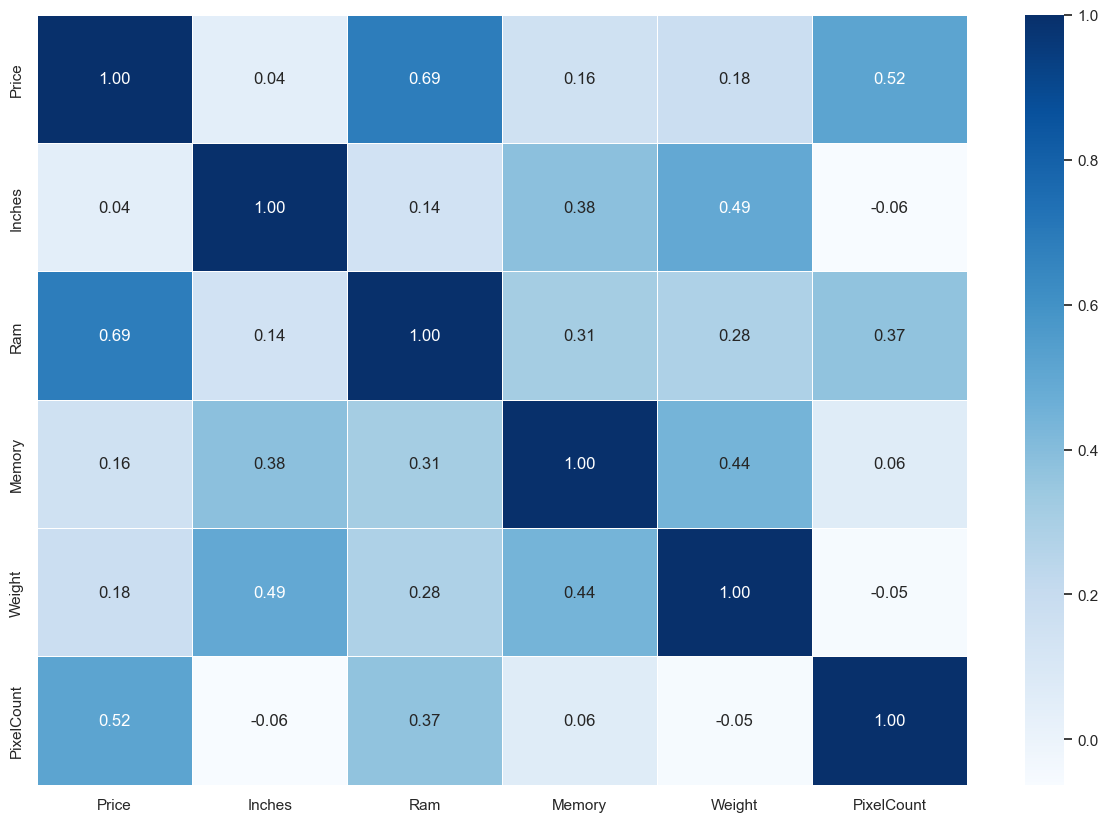

In [17]:
# here we examine the correlation between features in the dataset
numerical_corr = ['Price', 'Inches', 'Ram', 'Memory', 'Weight', 'PixelCount']
correlation_matrix = df[numerical_corr].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', linewidths=0.5, fmt='.2f')

## Step 6: Creating XGBoost Model

In [18]:
from sklearn.model_selection import train_test_split

# Split BEFORE sending into preprocessing
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [19]:
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_xgb_simple(
    train_df,
    test_df,
    cat_cols,                  # list of categorical column names
    custom_orders,             # dict: {col -> ordered list of categories}
    target_col="Price",
    log_target=True,
    num_boost_round=1000,
    random_state=42
):
    """
    XGBoost training with *fixed* ordinal encoding (domain-ordered categories).
    Unknown/unseen categories are encoded as -1.
    Returns RMSE, MAE, R², Adjusted R².
    """

    # --- Split features/target
    y_train = train_df[target_col].values
    X_train = train_df.drop(columns=[target_col]).copy()
    y_test  = test_df[target_col].values
    X_test  = test_df.drop(columns=[target_col]).copy()

    # --- Columns
    num_cols = [c for c in X_train.columns if c not in cat_cols]

    # categories list must align 1:1 with cat_cols
    categories_in_order = [custom_orders[c] for c in cat_cols]

    # --- Encoder with locked order
    enc = OrdinalEncoder(
        categories=categories_in_order,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    preproc = ColumnTransformer(
        transformers=[
            ("cat", enc, cat_cols),
            ("num", "passthrough", num_cols),
        ],
        remainder="drop"
    )

    # Fit on TRAIN only; transform both
    Xtr = preproc.fit_transform(X_train)
    Xte = preproc.transform(X_test)

    # ----- Center the encoded categorical features around 0 -----
    n_cat = len(cat_cols)
    if n_cat > 0:
        fitted_enc = preproc.named_transformers_["cat"]
        centers = np.array([(len(cats) - 1) / 2.0 for cats in fitted_enc.categories_], dtype=float)
        Xtr[:, :n_cat] = Xtr[:, :n_cat] - centers
        Xte[:, :n_cat] = Xte[:, :n_cat] - centers

    # --- Optional log-transform of target
    ytr_fit = np.log1p(y_train) if log_target else y_train

    # --- XGBoost params (no deprecated args)
    params = {
        "objective": "reg:squarederror",
        "eta": 0.03,
        "max_depth": 8,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
        "seed": random_state,
        "nthread": -1,
        "verbosity": 0,
    }

    dtrain = xgb.DMatrix(Xtr, label=ytr_fit)
    dtest  = xgb.DMatrix(Xte)
    model = xgb.train(params=params, dtrain=dtrain,
                      num_boost_round=num_boost_round, verbose_eval=False)

    # --- Predict (invert log if used)
    y_pred = model.predict(dtest)
    if log_target:
        y_pred = np.expm1(y_pred)

    # --- Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    n, p = X_test.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(n - p - 1, 1)

    return {
        "model": model,
        "preproc": preproc,
        "y_pred_test": y_pred,
        "rmse_test": rmse,
        "mae_test": mae,
        "r2_test": r2,
        "adj_r2_test": adj_r2
    }

In [20]:
cat_features = [
    'Company', 'TypeName', 'OpSys', 'Storage Type',
    'Cpu Brand Concise', 'Gpu Brand Concise', 'DisplayFeatures'
]

res = train_xgb_simple(
    train_df,
    test_df,
    cat_cols=cat_features,
    target_col="Price",
    custom_orders=custom_orders
)

print(f"✅ Test RMSE: {res['rmse_test']:.2f}")
print(f"✅ Test MAE:  {res['mae_test']:.2f}")
print(f"✅ Test R Squared:  {res['r2_test']:.2f}")
print(f"✅ Test Adjusted R Squared:  {res['adj_r2_test']:.2f}")

✅ Test RMSE: 54.83
✅ Test MAE:  33.41
✅ Test R Squared:  0.83
✅ Test Adjusted R Squared:  0.82


## Step 7: Interpreting Shapley Values for AI Explainability

In [21]:
import shap

# use your trained artifacts
model = res["model"]          # xgboost Booster from train_xgb_simple
preproc = res["preproc"]      # ColumnTransformer

# pick a set to explain (train or test). Here: test set (safer for audit)
X_test = test_df.drop(columns=["Price"]).copy()

# transform with the same preprocessor the model saw
X_enc = preproc.transform(X_test)

# (optional) downsample for speed when plotting
max_rows = 3000
if X_enc.shape[0] > max_rows:
    rng = np.random.default_rng(42)
    idx = rng.choice(X_enc.shape[0], size=max_rows, replace=False)
    X_enc_s = X_enc[idx]
    X_test_s = X_test.iloc[idx].reset_index(drop=True)
else:
    X_enc_s = X_enc
    X_test_s = X_test.reset_index(drop=True)

# build feature names (works across sklearn versions)
try:
    feature_names = preproc.get_feature_names_out()
except Exception:
    cat_cols = [t[2] for t in preproc.transformers_ if t[0] == "cat"][0]
    num_cols = [t[2] for t in preproc.transformers_ if t[0] == "num"][0]
    feature_names = np.array(list(cat_cols) + list(num_cols))

# SHAP explainer for tree models
explainer = shap.TreeExplainer(model)

# version-safe SHAP call
sv = explainer(X_enc_s)
shap_values = sv.values if hasattr(sv, "values") else sv  # older shap returns raw array
base_value = sv.base_values[0] if hasattr(sv, "base_values") else explainer.expected_value

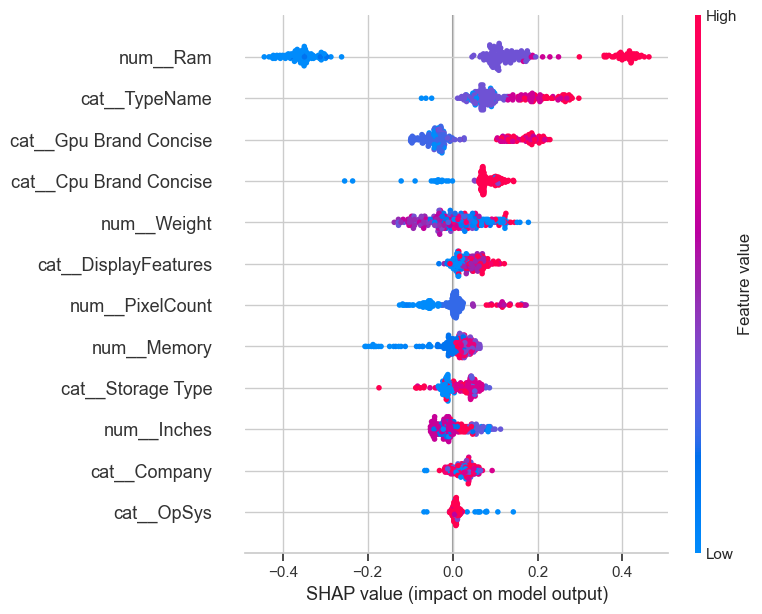

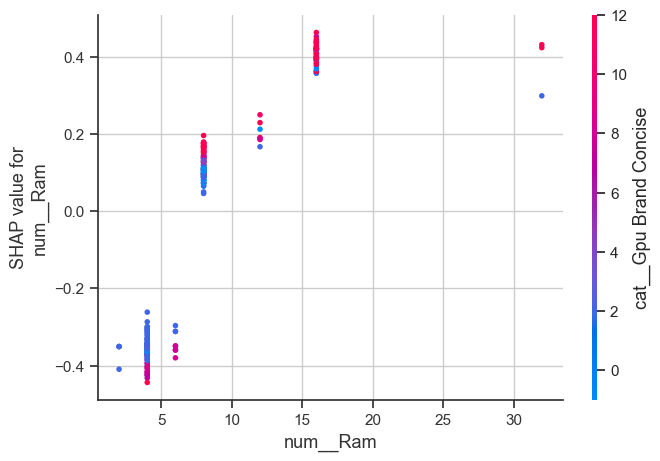

In [22]:
# 1) global view: which features matter most (be patient for rendering)
shap.summary_plot(shap_values, X_enc_s, feature_names=feature_names, show=True)

# 2) dependence plot for a top feature (edit the name after you see summary)
top_feature = feature_names[np.argsort(np.abs(shap_values).mean(0))[::-1][0]]
shap.dependence_plot(top_feature, shap_values, X_enc_s, feature_names=feature_names)

# 3) single row explanation (force plot)
shap.initjs()
row = 0  # choose any index within X_enc_s
shap.force_plot(base_value, shap_values[row, :], X_enc_s[row, :], feature_names=feature_names)

In [23]:
fitted_enc = res["preproc"].named_transformers_["cat"]

for col, cats in zip(cat_features, fitted_enc.categories_):
    print(f"\nMapping for '{col}':")
    n_cats = len(cats)
    center = (n_cats - 1) / 2  # midpoint used for centering
    for code, cat in enumerate(cats):
        centered_value = code - center
        print(f"  {cat!r:<35} -> raw {code:<3} | centered {centered_value:>6.2f}")
    print(f"  <UNKNOWN>                        -> -1 (raw) | centered {(-1 - center):>6.2f}")


Mapping for 'Company':
  'Vero'                              -> raw 0   | centered  -9.00
  'Mediacom'                          -> raw 1   | centered  -8.00
  'Chuwi'                             -> raw 2   | centered  -7.00
  'Google'                            -> raw 3   | centered  -6.00
  'Toshiba'                           -> raw 4   | centered  -5.00
  'Fujitsu'                           -> raw 5   | centered  -4.00
  'Xiaomi'                            -> raw 6   | centered  -3.00
  'Huawei'                            -> raw 7   | centered  -2.00
  'Acer'                              -> raw 8   | centered  -1.00
  'LG'                                -> raw 9   | centered   0.00
  'Asus'                              -> raw 10  | centered   1.00
  'MSI'                               -> raw 11  | centered   2.00
  'Razer'                             -> raw 12  | centered   3.00
  'HP'                                -> raw 13  | centered   4.00
  'Dell'                              

### Model Interpretation
The first SHAP visualization shows feature importance and direction of influence on predicted price.

---

### **Top Features and Their Effects**

#### 1. **RAM** *(Strong Positive Association)*
- **Most important feature.**
- Low RAM values drastically **decrease** predicted price.  
- Middling RAM values slightly **increase** predicted price.  
- High RAM values sharply **increase** predicted price.  
- Clear, smooth gradient — strong positive correlation with price.

####  2. **CPU Brand** *(Positive Association that tapers off as values become Positive)*
- **Second most important feature.**
- Low or middling values significantly **decrease** price
- High values slightly **increase** price

####  3. **Weight** *(Non-linear, possibly Parabolic Relationship)*
- **Third most important feature.**
- **Inconsistent** color transitions, suggesting nonlinear effects.  
- Middling weights tend to **decrease** price slightly.  
- Extremely low or high weights can sometimes **increase** price,  
  but lighter laptops are *generally* associated with higher prices.

####  4. **Storage Type** *(Weak Positive Association)*
- High values or mixed slightly **increase** price.  
- Lower values slightly **decrease** price.  
- The effect size is moderate compared to RAM or Weight.

####  5. **Type Name** *(Positive Association that Increases as values get more Positive)*
- High-end types (e.g., Workstation, Gaming) **increase** price strongly.  
- Middling types (e.g., Notebook) slightly **decrease** price.  
- Low-end types (e.g., Netbook) have little to no positive effect.

####  6. **Numerical Memory (Storage Capacity)** *(Positive Association that tapers off as values become Positive)*
- Low memory capacity **decreases** price consistently.  
- Middling or high values **increase** price slightly — weaker effect than RAM.
- **Inconsistent** color transitions, suggesting nonlinear effects.  

####  7. **Pixel Count** *(Positive Association that tapers off after middling values)*
- Middling or high pixel counts **increase** price.  
- Very low pixel counts **decrease** price significantly.
- Moderately low pixel counts do not impact price.

####  8. **Company** *(Non-linear, Inconsistent Weak Relationship, Negatives move price)*
- **Inconsistent** color transitions.  
- High values do not impact price.
- Low values sometimes **increase** price, sometimes **decrease** price.

####  9. **Inches** *(Weak Negative Association that Increases as values get more Negative)*
- **Inconsistent** color transitions.  
- Slight tendency for lower values to **increase** price.

####  10. **GPU Brand** *(Weak Positive Association that Increases as values get more Positive)*
- Low and middling GPUs (integrated) **decrease** price.  
- High-end GPUs (GTX, Quadro) **increase** price.  
- Smoother gradient than some other features.

####  11. **Operating System** *(Non-linear, Inconsistent Weak Relationship, Negatives move price)*
- **High-value OSs** (macOS, Windows 10) have very little impact on price, slightly positive.  
- **Low/mid-value OSs** (No OS, Linux, Android) sometimes increase price, sometimes decrease price.
- Overall weak influence.

####  12. **Display Features** *(Noisy Weak Positive Association)*
- **Least significant feature.**
- **Inconsistent** color transitions; no overt pattern.

---

###  **Feature Group Insights**

#### Hardware-Spec Features (Directly Related to Performance)
* 1. RAM  
* 2. CPU Brand
* 4. Storage Type   
* 6. Memory (Capacity)  
* 7. Pixel Count  
* 10. GPU Brand  
* 12. Display Features  

####  User/Product-Type Features (Indirect Influence)
* 3. Weight  
* 5. Type Name  
* 8. Company
* 9. Inches
* 11. Operating System    

 **Interpretation:**
- Most impactful features are hardware-performance related — especially **RAM** and **CPU Brand**.  
- **CPU importance > GPU importance** This makes sense when you consider the specialized use of GPUs. They excel on tasks that are computationally intensive
- and continuous (think 3d gaming). CPUs excel when computing smaller tasks quickly, like web browsing or making spreadsheets.
- GPUs may be more significant when combined with other features like laptop type. If the type of laptop is high end and the GPU is as well this *could* lead to a greater increase in price. 

## Step 8: Loading, Cleaning, using more data for K-fold Cross Validation

### Model Performance and Next Steps

Our results so far are **quality** — we've constructed a model that uses our **domain-specific order for categorical features** and our **cleaned numerical features** to achieve an **R² of 0.83**.

For context, an **R² of 0** would mean our model is explaining none of the variance in the dataset (essentially guessing the average for each prediction), while an **R² of 1** would mean our model explains all of the variation in the dataset — with each prediction being perfectly accurate.  
Given this context, **0.83 is quite good**.

---

#### Can We Get a Better Score?

While we are unlikely to improve our score with methods like feature transformations or interactions (trust me, I tried already), it is possible to get a better score by **training on more data**.

To give our model more information to work with, we will:
1. **Load more data**  
2. **Ensure it matches up exactly with our other dataset**  
3. **Use K-Fold Cross Validation** to train our model

---

#### What is K-Fold Cross Validation?

K-Fold splits our dataset into a specified number *(k)* of **“folds”**, then:
- Trains on all but one of those folds  
- Tests on the remaining one  
- Repeats this process until every fold has been used once for testing  

For example, if we set **k = 5**, we would have **5 sections** of the dataset:
- Round 1: Train on 4 folds, test on fold 1  
- Round 2: Train on 4 folds, test on fold 2  
- …and so on  

We then take the **average of the success metrics** from these rounds and evaluate the model.  
This gives the model more information to train on while also making our metrics more **robust**.


In [24]:
second_laptop_df = pd.read_csv(r"C:\Users\whoop\Downloads\kaggle_laptop_price.csv", encoding="cp1252", sep=None, engine="python")
second_laptop_df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [25]:
def euros_conversion():
    run_instance = 0
    if run_instance == 0:
        second_laptop_df['Price'] = second_laptop_df['Price_euros'] * 1.17
        second_laptop_df.drop(labels='Price_euros', axis=1, inplace=True)
    else: pass
euros_conversion()
display(second_laptop_df.head())

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1567.4373
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,1051.7598
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,672.7500
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2968.8165
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,2110.2120


In [26]:
display(second_laptop_df['Memory'].unique())
second_laptop_df['Storage Type'] = second_laptop_df['Memory'].apply(extract_storage_type)
second_laptop_df['Memory'] = second_laptop_df['Memory'].apply(total_storage_in_gb).astype('float64')
display(second_laptop_df['Storage Type'].unique())
display(second_laptop_df['Memory'].unique())
display(second_laptop_df.dtypes)

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '32GB Flash Storage', '128GB SSD +  1TB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  1TB HDD', '256GB SSD +  2TB HDD', '32GB SSD',
       '2TB HDD', '64GB SSD', '1.0TB Hybrid', '512GB SSD +  1TB HDD',
       '1TB SSD', '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

array(['SSD', 'Flash Storage', 'HDD', 'SSD + HDD', 'SSD + SSD', 'Hybrid',
       'Flash Storage + HDD', 'HDD + HDD', 'SSD + Hybrid'], dtype=object)

array([ 128.,  256.,  512.,  500., 1024.,   32., 1152.,   64., 1280.,
       2304., 2048., 1536.,  756., 2176.,   16.,  768., 2560., 1088.,
        180.,  240.,    8.,  508.])

laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory              float64
Gpu                  object
OpSys                object
Weight               object
Price               float64
Storage Type         object
dtype: object

In [27]:
display(second_laptop_df['Ram'].unique())
second_laptop_df['Ram'] = second_laptop_df['Ram'].apply(lambda x: re.sub('[^0-9.]', '', x) if isinstance(x, str) else x).replace('', np.nan).astype(('float64'))
display(second_laptop_df['Ram'].unique())
display(second_laptop_df.dtypes)

array(['8GB', '16GB', '4GB', '2GB', '12GB', '6GB', '32GB', '24GB', '64GB'],
      dtype=object)

array([ 8., 16.,  4.,  2., 12.,  6., 32., 24., 64.])

laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                 float64
Memory              float64
Gpu                  object
OpSys                object
Weight               object
Price               float64
Storage Type         object
dtype: object

In [28]:
second_laptop_df['Weight'] = second_laptop_df['Weight'].apply(lambda x: re.sub('[^0-9.]', '', x) if isinstance(x, str) else x).replace('', np.nan).astype(('float64'))
second_laptop_df['Weight'].replace(0.69, np.nan, inplace=True)
display(second_laptop_df['Weight'].unique())

C:\Users\whoop\AppData\Local\Temp\ipykernel_19756\4099885912.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  second_laptop_df['Weight'].replace(0.69, np.nan, inplace=True)


array([1.37 , 1.34 , 1.86 , 1.83 , 2.1  , 2.04 , 1.3  , 1.6  , 2.2  ,
       0.92 , 1.22 , 0.98 , 2.5  , 1.62 , 1.91 , 2.3  , 1.35 , 1.88 ,
       1.89 , 1.65 , 2.71 , 1.2  , 1.44 , 2.8  , 2.   , 2.65 , 2.77 ,
       3.2  ,   nan, 1.49 , 2.4  , 2.13 , 2.43 , 1.7  , 1.4  , 1.8  ,
       1.9  , 3.   , 1.252, 2.7  , 2.02 , 1.63 , 1.96 , 1.21 , 2.45 ,
       1.25 , 1.5  , 2.62 , 1.38 , 1.58 , 1.85 , 1.23 , 1.26 , 2.16 ,
       2.36 , 2.05 , 1.32 , 1.75 , 0.97 , 2.9  , 2.56 , 1.48 , 1.74 ,
       1.1  , 1.56 , 2.03 , 1.05 , 4.4  , 1.29 , 1.95 , 2.06 , 1.12 ,
       1.42 , 3.49 , 3.35 , 2.23 , 4.42 , 2.69 , 2.37 , 4.7  , 3.6  ,
       2.08 , 4.3  , 1.68 , 1.41 , 4.14 , 2.18 , 2.24 , 2.67 , 2.14 ,
       1.36 , 2.25 , 2.15 , 2.19 , 2.54 , 3.42 , 1.28 , 2.33 , 1.45 ,
       2.79 , 1.84 , 2.6  , 2.26 , 3.25 , 1.59 , 1.13 , 1.78 , 1.15 ,
       1.27 , 1.43 , 2.31 , 1.16 , 1.64 , 2.17 , 1.47 , 3.78 , 1.79 ,
       0.91 , 1.99 , 4.33 , 1.93 , 1.87 , 2.63 , 3.4  , 3.14 , 1.94 ,
       1.24 , 4.6  ,

In [29]:
CPU_PATTERNS = [
    (r'AMD A\d+[ -]Series', 'AMD Series'),
    (r'AMD E\d*[ -]Series', 'AMD Series'),
    (r'AMD Series', 'AMD Series'),
    (r'AMD FX(?:\s*\d+)?', 'AMD FX'),
    (r'AMD Ryzen(?:\s*\d+)?', 'AMD Ryzen'),
    (r'Intel Atom(?:\s*\w+)?', 'Intel Atom'),
    (r'Intel Celeron(?:\s+\w+)?', 'Intel Celeron'),
    (r'Intel Core i[3579](?:[- ]?\d{4,5}[A-Z]*)?', 'Intel Core'),
    (r'Intel Core M(?:\s*\w+)?', 'Intel Core'),
    (r'Intel Pentium(?:\s+\w+)?', 'Intel Pentium'),
    (r'Intel Xeon(?:.*)?', 'Intel Xeon')
]

second_laptop_df = extract_cpus(second_laptop_df, column='Cpu', new_column='Cpu Brand Concise')

display(second_laptop_df.head())
display(second_laptop_df['Cpu Brand Concise'].unique())

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Storage Type,Cpu Brand Concise
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,1.37,1567.4373,SSD,Intel Core
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,1.34,1051.7598,Flash Storage,Intel Core
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,1.86,672.7500,SSD,Intel Core
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,1.83,2968.8165,SSD,Intel Core
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,1.37,2110.2120,SSD,Intel Core


array(['Intel Core', 'AMD Series', 'Intel Atom', 'Intel Celeron',
       'AMD Ryzen', 'Intel Pentium', 'AMD FX', 'Intel Xeon', ''],
      dtype=object)

In [30]:
# Creating concise patterns in regex patterns to further narrow down GPU
GPU_PATTERNS = [
    (r'AMD\s+FirePro(?:\s*[\w-]+)?',                'AMD FirePro'),
    (r'AMD\s+Radeon\s+Pro(?:\s*[\w-]+)?',           'AMD Radeon Pro'),
    (r'AMD\s+Radeon\s+RX(?:\s*[\w-]+)?',            'AMD Radeon RX'),
    (r'AMD\s+Radeon(?!\s+(Pro|RX))(?:\s*[\w-]+)?',  'AMD Radeon'),
    (r'AMD\s+Graphics(?:\s*[\w-]+)?',               'AMD Graphics'),
    (r'ARM\s+Mali(?:\s*[\w-]+)?',                   'ARM Mali'),
    (r'Nvidia\s+GeForce\s+GTX(?:\s*[\w-]+)?',       'Nvidia GeForce GTX'),
    (r'Nvidia\s+GeForce\s+MX(?:\s*[\w-]+)?',        'Nvidia GeForce MX'),
    (r'Nvidia\s+Quadro(?:\s*[\w-]+)?',              'Nvidia Quadro'),
    (r'Intel\s+Iris\s+Pro\s+Graphics(?:\s*[\w-]+)?','Intel Iris Pro Graphics'),
    (r'Intel\s+Iris\s+Plus\s+Graphics(?:\s*[\w-]+)?','Intel Iris Plus Graphics'),
    (r'Intel\s+Iris\s+Graphics(?:\s*[\w-]+)?',      'Intel Iris Graphics'),
    (r'Intel\s+UHD\s+Graphics(?:\s*[\w-]+)?',       'Intel UHD Graphics'),
    (r'Intel\s+HD\s+Graphics(?:\s*[\w-]+)?',        'Intel HD Graphics'),
    (r'Intel\s+Graphics(?:\s*[\w-]+)?',             'Intel Graphics'),
]
second_laptop_df = extract_gpus(second_laptop_df, column='Gpu', new_column='Gpu Brand Concise')

display(second_laptop_df.head())
display(second_laptop_df['Gpu Brand Concise'].unique())

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Storage Type,Cpu Brand Concise,Gpu Brand Concise
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,1.37,1567.4373,SSD,Intel Core,Intel Iris Plus Graphics
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,1.34,1051.7598,Flash Storage,Intel Core,Intel HD Graphics
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,1.86,672.7500,SSD,Intel Core,Intel HD Graphics
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,1.83,2968.8165,SSD,Intel Core,AMD Radeon Pro
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,1.37,2110.2120,SSD,Intel Core,Intel Iris Plus Graphics


array(['Intel Iris Plus Graphics', 'Intel HD Graphics', 'AMD Radeon Pro',
       'AMD Radeon', 'Intel Iris Pro Graphics', 'Nvidia GeForce MX',
       'Intel UHD Graphics', '', 'Nvidia GeForce GTX',
       'Intel Iris Graphics', 'AMD Radeon RX', 'Nvidia Quadro',
       'AMD FirePro', 'Intel Graphics', 'ARM Mali'], dtype=object)

In [31]:
display(second_laptop_df['ScreenResolution'].unique())
# Applying parse_screen_resolution via a lambda and .apply
second_laptop_df[['PixelCount', 'DisplayFeatures']] = second_laptop_df['ScreenResolution'].apply(
    lambda x: pd.Series(parse_screen_resolution(x))
)
display(second_laptop_df['PixelCount'].unique())
display(second_laptop_df['DisplayFeatures'].unique())
display(second_laptop_df.head())

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800',
       'IPS Panel Touchscreen 1920x1200', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', 'Touchscreen 2560x1440',
       '1600x900', 'IPS Panel 4K Ultra HD 3840x2160',
       '4K Ultra HD 3840x2160', 'Touchscreen 1366x768',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel 

array([4096000., 1296000., 2073600., 5184000., 1049088., 3317760.,
       5760000., 2304000., 3393024., 8294400., 3110400., 3686400.,
       1440000., 4990464., 3840000.])

array(['Retina, IPS Panel', nan, 'Full HD', 'Full HD, IPS Panel',
       'Full HD, Touchscreen, IPS Panel', 'Full HD, Touchscreen',
       'Touchscreen', 'Touchscreen, IPS Panel', 'IPS Panel',
       '4K, Touchscreen, IPS Panel', '4K, Touchscreen',
       'Touchscreen, QHD', '4K, IPS Panel', '4K', 'IPS Panel, QHD',
       'Full HD, IPS Panel, QHD', 'QHD', 'Touchscreen, IPS Panel, QHD'],
      dtype=object)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Storage Type,Cpu Brand Concise,Gpu Brand Concise,PixelCount,DisplayFeatures
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128.0,Intel Iris Plus Graphics 640,macOS,1.37,1567.4373,SSD,Intel Core,Intel Iris Plus Graphics,4096000.0,"Retina, IPS Panel"
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128.0,Intel HD Graphics 6000,macOS,1.34,1051.7598,Flash Storage,Intel Core,Intel HD Graphics,1296000.0,NaN
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256.0,Intel HD Graphics 620,No OS,1.86,672.7500,SSD,Intel Core,Intel HD Graphics,2073600.0,Full HD
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512.0,AMD Radeon Pro 455,macOS,1.83,2968.8165,SSD,Intel Core,AMD Radeon Pro,5184000.0,"Retina, IPS Panel"
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256.0,Intel Iris Plus Graphics 650,macOS,1.37,2110.2120,SSD,Intel Core,Intel Iris Plus Graphics,4096000.0,"Retina, IPS Panel"


In [32]:
df2 = second_laptop_df.drop(['ScreenResolution', 'Cpu', 'Gpu', 'Product', 'laptop_ID'], axis=1)
display(df2.head())
display(df.head())

,Company,TypeName,Inches,Ram,Memory,OpSys,Weight,Price,Storage Type,Cpu Brand Concise,Gpu Brand Concise,PixelCount,DisplayFeatures
0,Apple,Ultrabook,13.3,8.0,128.0,macOS,1.37,1567.4373,SSD,Intel Core,Intel Iris Plus Graphics,4096000.0,"Retina, IPS Panel"
1,Apple,Ultrabook,13.3,8.0,128.0,macOS,1.34,1051.7598,Flash Storage,Intel Core,Intel HD Graphics,1296000.0,NaN
2,HP,Notebook,15.6,8.0,256.0,No OS,1.86,672.7500,SSD,Intel Core,Intel HD Graphics,2073600.0,Full HD
3,Apple,Ultrabook,15.4,16.0,512.0,macOS,1.83,2968.8165,SSD,Intel Core,AMD Radeon Pro,5184000.0,"Retina, IPS Panel"
4,Apple,Ultrabook,13.3,8.0,256.0,macOS,1.37,2110.2120,SSD,Intel Core,Intel Iris Plus Graphics,4096000.0,"Retina, IPS Panel"


,Company,TypeName,Inches,Ram,Memory,OpSys,Weight,Price,Storage Type,Cpu Brand Concise,Gpu Brand Concise,PixelCount,DisplayFeatures
0,Apple,Ultrabook,13.3,8.0,128.0,macOS,1.37,250.539429,SSD,Intel Core,Intel Iris Plus Graphics,4096000.0,"Retina, IPS Panel"
1,Apple,Ultrabook,13.3,8.0,128.0,macOS,1.34,168.113455,Flash Storage,Intel Core,Intel HD Graphics,1296000.0,NaN
2,HP,Notebook,15.6,8.0,256.0,No OS,1.86,107.532468,SSD,Intel Core,Intel HD Graphics,2073600.0,Full HD
3,Apple,Ultrabook,15.4,16.0,512.0,macOS,1.83,474.536104,SSD,Intel Core,AMD Radeon Pro,5184000.0,"Retina, IPS Panel"
4,Apple,Ultrabook,13.3,8.0,256.0,macOS,1.37,337.296623,SSD,Intel Core,Intel Iris Plus Graphics,4096000.0,"Retina, IPS Panel"


Take note that the prices are drastically different


 Missing Values in Data:


DisplayFeatures    311
Weight               4
dtype: int64

C:\Users\whoop\AppData\Local\Temp\ipykernel_19756\3992469157.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=missing.index, x=missing.values, palette="viridis")


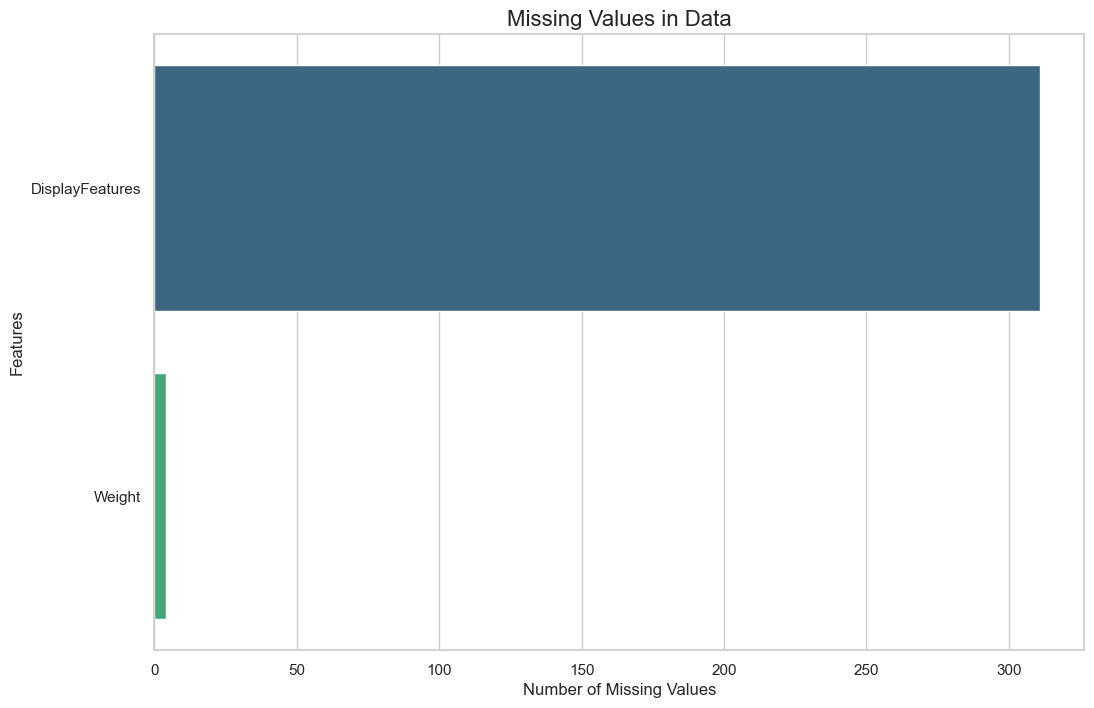

In [33]:
# 🔍 Check missing values for Training data
missing = df2.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\n Missing Values in Data:")
display(missing)

# 📊 Visualizing missing values (train data)
plt.figure(figsize=(12, 8))
sns.barplot(y=missing.index, x=missing.values, palette="viridis")
plt.title('Missing Values in Data', fontsize=16)
plt.xlabel('Number of Missing Values')
plt.ylabel('Features')
plt.show()

In [34]:
# This cell addresses missing values
df2 = df2.copy()

# 1 Drop rows with missing target
df2 = df2.dropna(subset=['Price'])

# 2 Categorical fills
cat_fill = {
    'DisplayFeatures': 'None',
    'Storage Type': 'Unknown',
    'TypeName': 'Unknown',
    'Company': 'Unknown',
    'OpSys': 'Unknown'
}
df2.fillna(value=cat_fill)

# 3 Numeric fills
num_cols = ['Memory', 'Inches', 'Weight', 'Ram', 'PixelCount']
for col in num_cols:
    df2[col].fillna(df2[col].median())

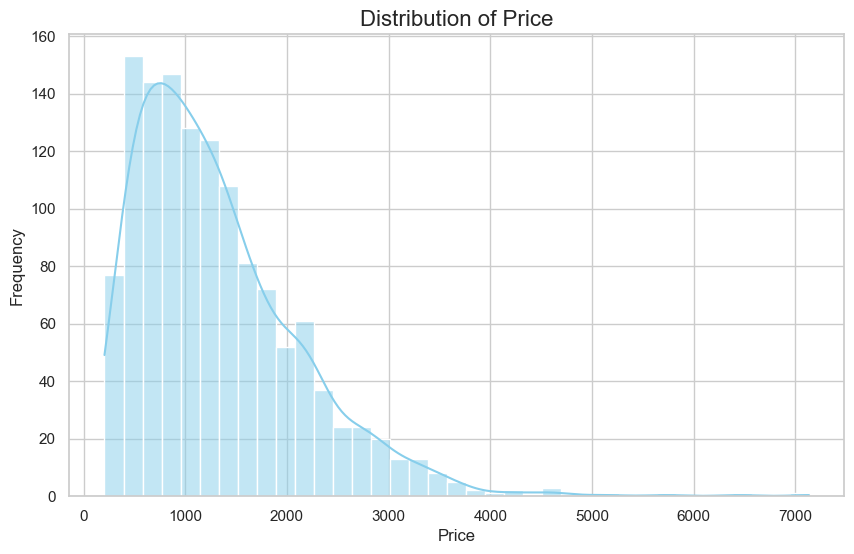

In [35]:
plt.figure(figsize=(10,6))
sns.histplot(df2['Price'], kde=True, color='skyblue')
plt.title('Distribution of Price', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [36]:
factor = df['Price'].median() / df2['Price'].median()
print(f"Estimated scaling factor ≈ {factor:.2f}")

Estimated scaling factor ≈ 0.16


In [37]:
df['Price'] = df['Price'] / factor

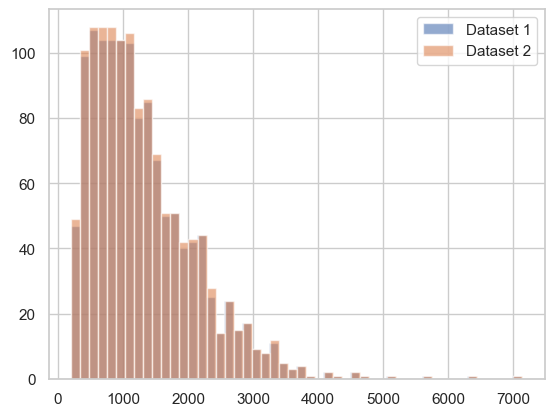

In [38]:
import matplotlib.pyplot as plt

plt.hist(df['Price'], bins=50, alpha=0.6, label='Dataset 1')
plt.hist(df2['Price'], bins=50, alpha=0.6, label='Dataset 2')
plt.legend()
plt.show()

In [39]:
display(df.shape)
display(df2.shape)
merged_df = pd.concat([df, df2], ignore_index=True)
display(merged_df.shape)

(1273, 13)

(1303, 13)

(2576, 13)

✅ 5-Fold CV R² Mean: 0.9199 ± 0.0345
✅ Test RMSE: 164.39
✅ Test MAE:  112.98
✅ Test R Squared:  0.96
✅ Test Adjusted R Squared:  0.96


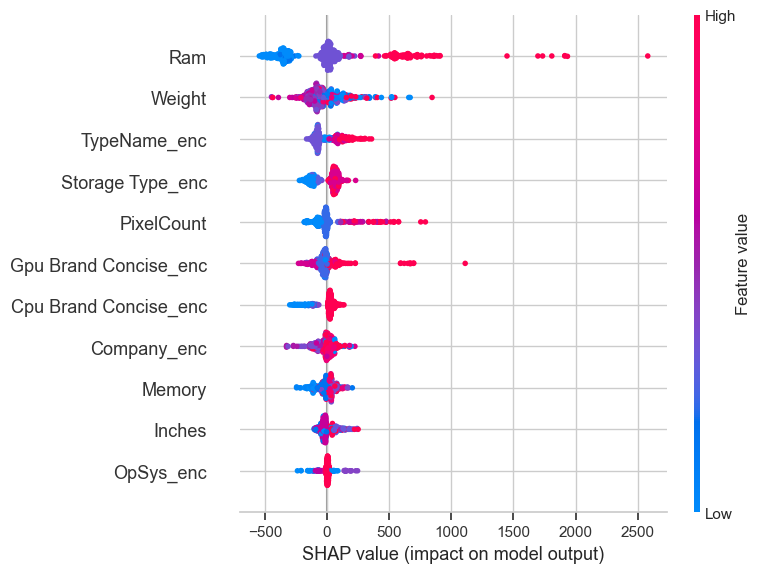

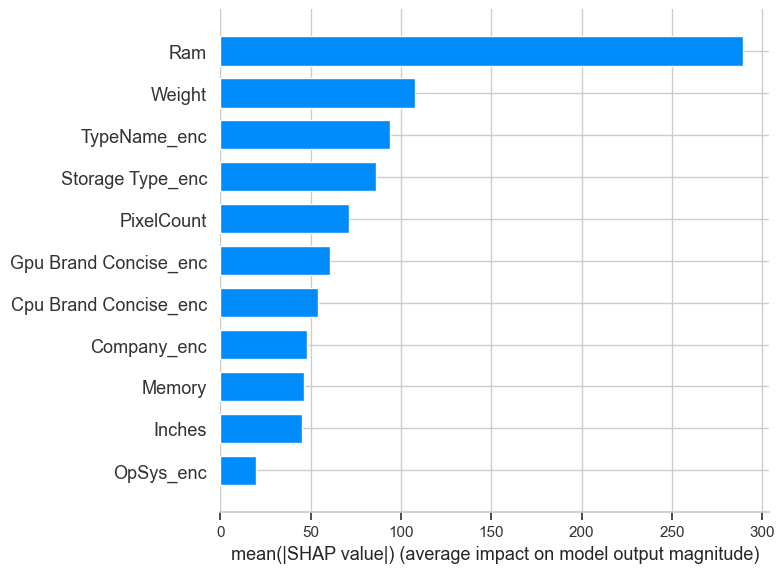

In [40]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# Configuration 
TARGET = "Price"

# Original columns present in merged_df
NUM_COLS_RAW = ["Ram", "Memory", "Weight", "Inches", "PixelCount"]
ORDINAL_COLS  = ["Company", "OpSys", "TypeName", "Cpu Brand Concise", "Gpu Brand Concise", "Storage Type"]

# Build df_feat (no interactions). Ordinals will be encoded numerically below.
def build_base_df(df: pd.DataFrame) -> pd.DataFrame:
    df_feat = df[NUM_COLS_RAW + ORDINAL_COLS + [TARGET]].copy()

    # numerics as numeric
    for c in NUM_COLS_RAW:
        if c in df_feat.columns:
            df_feat[c] = pd.to_numeric(df_feat[c], errors="coerce")

    # keep ordinals as strings for now (we'll map to ints using custom_orders)
    for c in ORDINAL_COLS:
        if c in df_feat.columns:
            df_feat[c] = df_feat[c].astype(str)

    df_feat = df_feat.dropna(subset=[TARGET]).reset_index(drop=True)
    return df_feat

df_feat = build_base_df(merged_df)

# Encode ordinals using explicit custom_orders
def ensure_ordinal_encodings(df: pd.DataFrame, cols, custom_orders, suffix="_enc"):
    df = df.copy()
    for col in cols:
        if col not in custom_orders:
            raise KeyError(f"custom_orders missing list for column '{col}'")
        order = custom_orders[col]
        mapping = {cat: i for i, cat in enumerate(order)}
        df[f"{col}{suffix}"] = df[col].map(mapping).fillna(-1).astype(float)  # -1 for unknowns
    return df

df_feat = ensure_ordinal_encodings(df_feat, ORDINAL_COLS, custom_orders, suffix="_enc")

MODEL_COLS = NUM_COLS_RAW + [f"{c}_enc" for c in ORDINAL_COLS]

def make_pipeline(all_numeric_cols, xgb_params=None) -> Pipeline:
    xgb_params = xgb_params or dict(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=42, tree_method="hist",
    )
    preproc = ColumnTransformer(
        transformers=[("num", "passthrough", all_numeric_cols)],
        remainder="drop",
    )
    model = XGBRegressor(**xgb_params)
    return Pipeline([("prep", preproc), ("model", model)])

# K-Fold CV
from sklearn.model_selection import KFold, cross_val_score

def kfold_cv_r2(df_feat, target, model_cols, k_folds=5, random_state=42):
    """Runs K-Fold CV and prints mean±std R²."""
    X = df_feat[model_cols]
    y = df_feat[target].values

    pipe = make_pipeline(model_cols)
    cv = KFold(n_splits=k_folds, shuffle=True, random_state=random_state)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2", n_jobs=-1)

    print(f"✅ {k_folds}-Fold CV R² Mean: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores

# Train/Test fit, metrics, SHAP plots
def train_test_fit_with_shap(
    df_feat: pd.DataFrame,
    target: str,
    model_cols,
    test_size: float = 0.2,
    random_state: int = 42,
    shap_sample: int = 2000,
):
    X = df_feat[model_cols]
    y = df_feat[target].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    pipe = make_pipeline(model_cols)
    pipe.fit(X_train, y_train)

    #  metrics 
    y_pred = pipe.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))

    # adjusted R^2 uses post-preprocessing dimensionality
    X_test_t = pipe.named_steps["prep"].transform(X_test)
    p = X_test_t.shape[1]
    n = X_test_t.shape[0]
    adj_r2 = float(1 - (1 - r2) * (n - 1) / (max(n - p - 1, 1)))

    res = {
        "rmse_test": rmse,
        "mae_test": mae,
        "r2_test": r2,
        "adj_r2_test": adj_r2,
        "n_test": n,
        "p_effective": p,
    }

    print(f"✅ Test RMSE: {res['rmse_test']:.2f}")
    print(f"✅ Test MAE:  {res['mae_test']:.2f}")
    print(f"✅ Test R Squared:  {res['r2_test']:.2f}")
    print(f"✅ Test Adjusted R Squared:  {res['adj_r2_test']:.2f}")

    # ---- SHAP ----
    shap.initjs()
    feature_names = model_cols  
    rng = np.random.RandomState(42)
    if n > shap_sample:
        idx = rng.choice(n, size=shap_sample, replace=False)
        X_shap = X_test_t[idx]
    else:
        X_shap = X_test_t

    model = pipe.named_steps["model"]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=True)
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", show=True)

    return pipe, res, feature_names

# ---- 7) Run it ----
_ = kfold_cv_r2(df_feat, TARGET, MODEL_COLS, k_folds=5)           
model, res, feat_names = train_test_fit_with_shap(df_feat, TARGET, MODEL_COLS)  

## Summary:

In the above code, models, and explanations, we can see that within the world of **laptop sales** there are some **highly indicative features** that allow us to predict price with high accuracy.  

Typically, laptops with the **best RAM (Random Access Memory)** will have the highest price. **Weight** also impacts the prediction of price substantially, as expected — a lightweight laptop will have an appeal to consumers, but so will a particularly bulky one that comes with **outstanding performance**.  

The **type of laptop** heavily impacts price: **workstations and gaming laptops** stand above the rest. The rest of the features are instrumental in completing our prediction, but their predictive power is not the same as that of the most pertinent features.  

Weight, RAM, and Type all make sense when we note the fact that these are laptops; the main appeal of a laptop is its **portability**, **ability to compute basic tasks**, and **usefulness in context**.  

Further work will be done on this project to ensure this **model framework performs well on more unseen data**.
